In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up two levels (from numerics to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures

# Learning Boltzmann distributions

The energy function of the **target distribution** with n sites and open boundary conditions is given as
$$E(s)=\sum_i s_i + \sum_i s_i s_{i+1} + \frac{1}{2} \sum_i s_i s_{i+2} \ \ \longrightarrow \ \ p(s) \propto e^{-\beta E(s)}$$

In [3]:
# Target p(s)
# s is a bitstring in {0,1}^n; map to spins via s_i = 1 - 2*b_i  (0->+1, 1->-1)
function nnn_boltzmann_p(nq::Int; beta::Float64=1.0)
    d = 1 << nq
    E = zeros(Float64, d)
    @inbounds for s in 0:d-1
        # spins s_i in {+1,-1}
        # bit i (1-based in math) corresponds to bit (i-1)
        # s_i = +1 if bit=0, -1 if bit=1
        E1 = 0.0
        E2 = 0.0
        E3 = 0.0
        @inbounds for i in 1:nq
            bi = (s >> (i-1)) & 0x1
            si = 1.0 - 2.0*bi
            E1 += si
            if i <= nq-1
                bj = (s >> i) & 0x1
                sj = 1.0 - 2.0*bj
                E2 += si*sj
            end
            if i <= nq-2
                bk = (s >> (i+1)) & 0x1
                sk = 1.0 - 2.0*bk
                E3 += si*sk
            end
        end
        # E(s) = sum_i s_i + sum_i s_i s_{i+1} + 0.5 * sum_i s_i s_{i+2}
        E[s+1] = E1 + E2 + 0.5*E3
    end
    # p(s) ∝ exp(-β E(s))
    @inbounds for i in eachindex(E); E[i] = exp(-beta * E[i]); end
    Z = sum(E)
    @. E = E / Z
    return E   # this is p(s), length 2^n
end

nnn_boltzmann_p (generic function with 1 method)

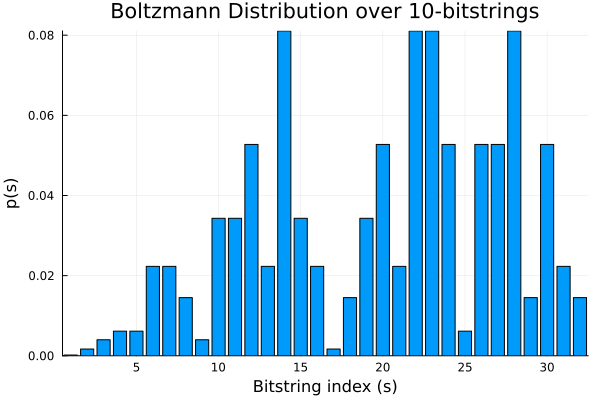

In [14]:
p = nnn_boltzmann_p(5, beta=0.40)

bar(p,
    xlabel="Bitstring index (s)", 
    ylabel="p(s)", 
    title="Boltzmann Distribution over 10-bitstrings",
    legend=false,
    xlims=(0.5, length(p)+0.5)
)

Choose a setting where both models and target distributions are built with up to two-body interactions

Train two types of BMs and QBMs on the eight site next-nearest-neighbor target distribution. BM uses the ising and QBM uses the generic Hamiltonian

The first type is the all-to-all connected model. In this case, both the BM and QBM can perfectly learn (DKL = 0) and represent the next-nearestneighbor target distribution. Having all-to-all connectivity allows both models to represent high-dimensional target distributions. In the second type, we restrict the connectivity of both models to nearest-neighbor (NN) with open boundary conditions. This way, both models are restricted to one dimension, while the target has two dimensions. In this case, the QBM (DKL = 0.15) approximates the target distribution much better than the BM (DKL = 0.4).